# Customer Segmentation Model

**Objective:** Identify distinct population segments that can be translated into differentiated outreach and product strategy.

**Approach:**
To keep segments interpretable and business-usable, clustering is run on a curated feature subset (instead of all fields).

1. **Feature Selection & Preprocessing:** Select practical demographic and economic drivers; scale numeric features and encode categorical features.
2. **Cluster Formation:** Use K-Means and justify `k` with both visual and quantitative diagnostics.
3. **Segment Interpretation:** Use feature importance and weighted profiling to explain each segment.
4. **Business Application:** Translate segment profiles into concrete targeting actions and prioritization logic.

In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load column names
with open('census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines()]

# Load the main dataset
df = pd.read_csv('census-bureau.data', names=columns, header=None)

# Preview the first few rows
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


## 1. Feature Selection & Preprocessing
We select variables that are both behaviorally meaningful and stable enough for segmentation (demographics, work attachment, and economic indicators).

Preprocessing is designed for distance-based clustering:
- scale numeric features to prevent large-range variables from dominating distance
- one-hot encode categorical features so categorical similarity is represented consistently

In [8]:
# 1. Select a curated subset of logical features for segmentation
cluster_cols = [
    'age', 'education', 'sex', 'marital stat', 
    'major occupation code', 'wage per hour', 'capital gains'
]

X_cluster = df[cluster_cols].copy()

# 2. Identify column types
cluster_cat_cols = X_cluster.select_dtypes(include=['object', 'category']).columns.tolist()
cluster_num_cols = X_cluster.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Create the preprocessor
# Note: sparse_output=False is required for K-Means to read the data correctly
cluster_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cluster_num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cluster_cat_cols) 
    ])

# 4. Apply the transformations
X_cluster_processed = cluster_preprocessor.fit_transform(X_cluster)
print("Data successfully preprocessed for clustering.")

Data successfully preprocessed for clustering.


## 2. K-Selection: Choosing the Number of Segments
Selecting `k` is a model decision with business consequences: too few clusters oversimplifies behavior, too many clusters reduce usability.

We first use the **Elbow Method** (inertia) to identify the point of diminishing returns, then validate with quantitative quality metrics in the next section.

Calculating inertia for various cluster sizes...


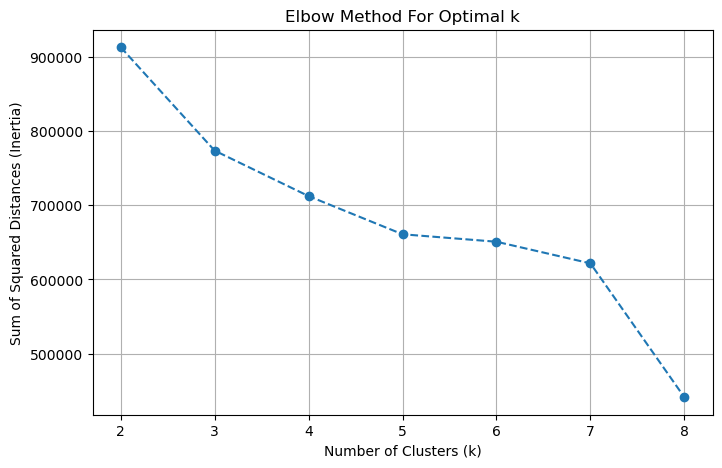

In [9]:
# Test K values from 2 to 8 to find the "elbow"
sse = []
k_range = range(2, 9)

print("Calculating inertia for various cluster sizes...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster_processed)
    sse.append(km.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.grid(True)
plt.show()

## 2.1 Cluster Quality Diagnostics
To support a more defensible `k` choice, we compare cluster quality metrics across candidate values:

- **Silhouette** (higher is better)
- **Calinski-Harabasz** (higher is better)
- **Davies-Bouldin** (lower is better)

These do not replace business judgment, but help confirm the selected segmentation is structurally coherent.

In [10]:
# Quantitative cluster-quality checks for candidate k values
# Note: silhouette can be expensive on large datasets, so we use a reproducible sample.

quality_rows = []
max_diag_rows = 30000
rng = np.random.default_rng(42)

if X_cluster_processed.shape[0] > max_diag_rows:
    sample_idx = rng.choice(X_cluster_processed.shape[0], size=max_diag_rows, replace=False)
    X_diag = X_cluster_processed[sample_idx]
    print(f'Using sampled subset for diagnostics: {max_diag_rows:,} rows')
else:
    X_diag = X_cluster_processed
    print(f'Using full dataset for diagnostics: {X_diag.shape[0]:,} rows')

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels_k = km.fit_predict(X_diag)

    quality_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_diag, labels_k),
        'calinski_harabasz': calinski_harabasz_score(X_diag, labels_k),
        'davies_bouldin': davies_bouldin_score(X_diag, labels_k)
    })

quality_df = pd.DataFrame(quality_rows)
print('Cluster quality diagnostics across candidate k values:')
display(quality_df.round(4))

Using sampled subset for diagnostics: 30,000 rows
Cluster quality diagnostics across candidate k values:


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.2469,7424.3716,1.5485
1,3,0.2316,5214.5502,2.2364
2,4,0.2573,5959.4333,1.7691
3,5,0.2582,8121.0082,1.4042
4,6,0.2600,7777.3200,1.4367
5,7,0.2473,6953.8367,1.5427
6,8,0.2378,6445.2125,1.5867


## 3. K-Means Clustering
Using the elbow pattern and quality diagnostics together, we proceed with `k = 5` to balance:
- differentiation across groups
- stability of cluster structure
- practical usability for downstream business planning

In [11]:
# Fit K-Means Clustering
print("Building 5 customer segments using K-Means...")
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster_processed)

# Add the resulting cluster labels back to our dataframes
df['Segment'] = cluster_labels
X_cluster['Segment'] = cluster_labels

print("Segmentation complete! Overview of raw segment sizes:")
print(df['Segment'].value_counts().sort_index())

Building 5 customer segments using K-Means...
Segmentation complete! Overview of raw segment sizes:
Segment
0    58019
1    50158
2     7814
3    32333
4    51199
Name: count, dtype: int64


## 4. Interpreting the Segments (Feature Drivers)
K-Means does not directly provide feature importance. To interpret segment structure, we train a shallow Random Forest model to predict cluster labels from the processed inputs.

The resulting importances provide a practical explanation of which variables most strongly separate segments.

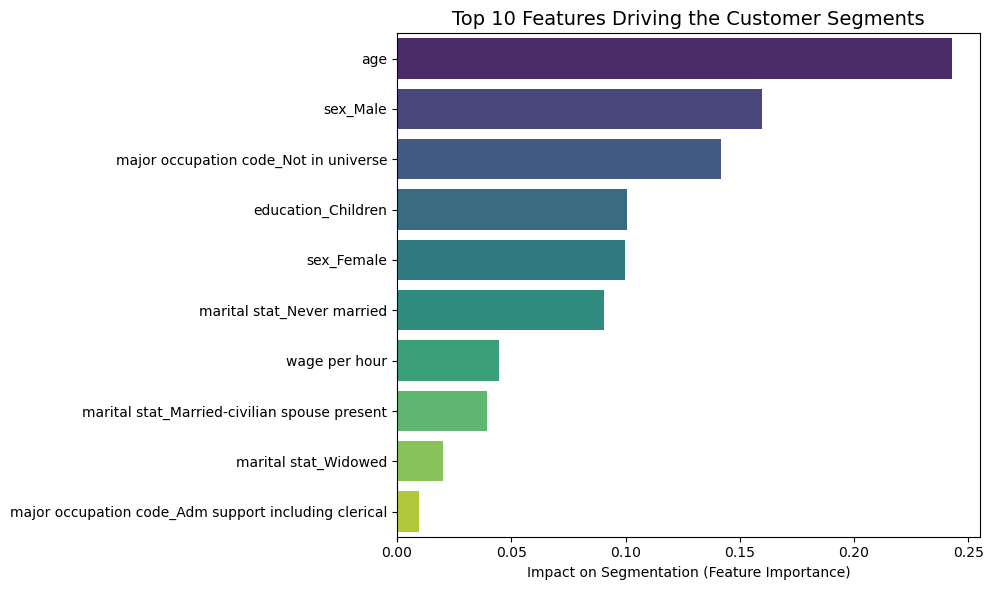

In [12]:
# 1. Train a Random Forest to "explain" the clusters
rf_explainer = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_explainer.fit(X_cluster_processed, cluster_labels)

# 2. Extract feature names
ohe_feature_names = cluster_preprocessor.named_transformers_['cat'].get_feature_names_out(cluster_cat_cols)
all_feature_names = cluster_num_cols + list(ohe_feature_names)

# 3. Map names to importances
importances = rf_explainer.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

# 4. Plot the top 10 impactful features
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features Driving the Customer Segments', fontsize=14)
plt.xlabel('Impact on Segmentation (Feature Importance)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Weighted Segment Profiling & Income Distribution
To make segment insights population-representative, all profile summaries are weighted by the provided `weight` field.

We also add `income_>50k` as an external lens (not used to create clusters) to estimate each segment’s relative earning concentration and business opportunity.

In [13]:
# 1. Bring the target label and population weights into our cluster dataframe
X_cluster['weight'] = df['weight']
X_cluster['income_>50k'] = np.where(df['label'].astype(str).str.contains('+', regex=False), 1, 0)

# 2. Helper function for weighted averages
def weighted_average(group, col, weight_col):
    return np.average(group[col], weights=group[weight_col])

# 3. Build the profile summary
profile_summary = []
total_weight = X_cluster['weight'].sum()
overall_hi_income_rate = weighted_average(X_cluster, 'income_>50k', 'weight') * 100

for cluster in sorted(X_cluster['Segment'].unique()):
    subset = X_cluster[X_cluster['Segment'] == cluster]

    pop_share = (subset['weight'].sum() / total_weight) * 100
    pct_high_income = weighted_average(subset, 'income_>50k', 'weight') * 100
    lift_vs_population = pct_high_income / overall_hi_income_rate if overall_hi_income_rate > 0 else np.nan

    avg_age = weighted_average(subset, 'age', 'weight')
    top_edu = subset['education'].mode()[0]
    top_occ = subset['major occupation code'].mode()[0]
    top_marital = subset['marital stat'].mode()[0]

    # Opportunity index balances quality (income concentration) and scale (population share)
    opportunity_index = pop_share * (pct_high_income / 100)

    profile_summary.append({
        'Segment': cluster,
        'Pop. Share (%)': pop_share,
        '>50K Earners (%)': pct_high_income,
        'Lift vs Pop Avg (x)': lift_vs_population,
        'Opportunity Index': opportunity_index,
        'Avg Age': avg_age,
        'Top Marital Stat': top_marital,
        'Top Education': top_edu,
        'Top Occupation': top_occ
    })

# 4. Display profile table and a priority ranking view
profile_df = pd.DataFrame(profile_summary).round(2)
priority_df = profile_df.sort_values(['Opportunity Index', 'Lift vs Pop Avg (x)'], ascending=False).reset_index(drop=True)

print(f'Overall weighted >50K rate in population: {overall_hi_income_rate:.2f}%')
print('\nWeighted segment profile:')
display(profile_df)

print('\nSegment priority ranking (by Opportunity Index, then Lift):')
display(priority_df[['Segment', 'Pop. Share (%)', '>50K Earners (%)', 'Lift vs Pop Avg (x)', 'Opportunity Index']])

Overall weighted >50K rate in population: 6.41%

Weighted segment profile:


,Segment,Pop. Share (%),>50K Earners (%),Lift vs Pop Avg (x),Opportunity Index,Avg Age,Top Marital Stat,Top Education,Top Occupation
0,0,28.22,0.01,0.00,0.00,9.06,Never married,Children,Not in universe
1,1,26.27,17.30,2.70,4.54,37.76,Married-civilian spouse present,High school graduate,Precision production craft & repair
2,2,4.05,6.63,1.03,0.27,38.56,Married-civilian spouse present,High school graduate,Adm support including clerical
3,3,15.85,3.07,0.48,0.49,70.00,Married-civilian spouse present,High school graduate,Not in universe
4,4,25.60,4.30,0.67,1.10,36.47,Married-civilian spouse present,High school graduate,Adm support including clerical



Segment priority ranking (by Opportunity Index, then Lift):


,Segment,Pop. Share (%),>50K Earners (%),Lift vs Pop Avg (x),Opportunity Index
0,1,26.27,17.30,2.70,4.54
1,4,25.60,4.30,0.67,1.10
2,3,15.85,3.07,0.48,0.49
3,2,4.05,6.63,1.03,0.27
4,0,28.22,0.01,0.00,0.00


## 6. Marketing Strategies & Business Application

The segmentation output can be operationalized through a two-step planning approach:

1. **Segment-level strategy:** choose product/message by segment profile.
2. **Within-segment prioritization:** allocate budget first to segments with stronger lift and opportunity index.

Example segment actions (aligned to observed profiles):

- **Segment 0: Dependents-heavy population**
  - **Profile:** very young age structure, near-zero direct high-income concentration.
  - **Action:** indirect household targeting via parent-focused products (education savings, youth onboarding, family protection bundles).

- **Segment 1: Established working households**
  - **Profile:** higher concentration of `>50K`, stable employment/marital characteristics.
  - **Action:** prioritize higher-value lending and rewards offers; this segment is a primary conversion target.

- **Segment 3: Retirement-oriented households**
  - **Profile:** older age structure and low active-work indicators.
  - **Action:** emphasize asset protection, fixed-income products, fraud protection, and service stability.

- **Segments 2 and 4: Middle-income administrative core**
  - **Profile:** moderate income concentration with meaningful population share.
  - **Action:** focus on everyday banking value propositions (no-fee checking, cash-back cards, debt consolidation support).

### Implementation notes
- Recompute this segmentation periodically if data distribution shifts.
- Use weighted metrics when tracking segment performance over time.
- Pair this notebook with the classification notebook for execution: segment for strategy, then rank customers within segment by predicted propensity.

## 7. Limitations and Next Steps

- K-Means assumes centroid-based cluster geometry; alternative methods (e.g., Gaussian Mixtures or hierarchical clustering) can be tested for robustness.
- One-hot encoded high-cardinality variables may dilute distance quality; feature grouping can improve stability.
- Cluster labels are not fixed personas over time; monitor drift and refresh segmentation on a regular cadence.
- To validate business impact, run pilot campaigns and compare response uplift by segment versus non-segmented targeting.

## 8. Robustness Check: K-Means vs Hierarchical vs GMM
To validate the modeling choice, we compare three clustering families on the same processed feature space and the same `k = 5`:
- K-Means
- Agglomerative (hierarchical)
- Gaussian Mixture Model (GMM)

Because hierarchical clustering is computationally expensive on very large datasets, this benchmark uses a reproducible sample and reports:
- Silhouette score (higher is better)
- Calinski-Harabasz score (higher is better)
- Davies-Bouldin score (lower is better)
- Runtime (seconds; lower is better)

This does not mathematically "prove" one algorithm is always best, but provides practical, dataset-specific evidence for model choice.

In [21]:
# Compare K-Means vs Hierarchical (Agglomerative) vs GMM at k=5 on same sample
compare_k = 5
max_compare_rows = 8000
rng = np.random.default_rng(42)

if X_cluster_processed.shape[0] > max_compare_rows:
    compare_idx = rng.choice(X_cluster_processed.shape[0], size=max_compare_rows, replace=False)
    X_compare = X_cluster_processed[compare_idx]
    print(f'Using sampled subset for model comparison: {max_compare_rows:,} rows')
else:
    X_compare = X_cluster_processed
    print(f'Using full dataset for model comparison: {X_compare.shape[0]:,} rows')

results = []

# 1) K-Means
start = time.time()
km_cmp = KMeans(n_clusters=compare_k, random_state=42)
labels_km = km_cmp.fit_predict(X_compare)
km_time = time.time() - start

results.append({
    'Model': 'K-Means',
    'Silhouette': silhouette_score(X_compare, labels_km),
    'Calinski-Harabasz': calinski_harabasz_score(X_compare, labels_km),
    'Davies-Bouldin': davies_bouldin_score(X_compare, labels_km),
    'Runtime (sec)': km_time
})

# 2) Hierarchical (Ward linkage)
start = time.time()
agg_cmp = AgglomerativeClustering(n_clusters=compare_k, linkage='ward')
labels_agg = agg_cmp.fit_predict(X_compare)
agg_time = time.time() - start

results.append({
    'Model': 'Hierarchical (Agglomerative, ward)',
    'Silhouette': silhouette_score(X_compare, labels_agg),
    'Calinski-Harabasz': calinski_harabasz_score(X_compare, labels_agg),
    'Davies-Bouldin': davies_bouldin_score(X_compare, labels_agg),
    'Runtime (sec)': agg_time
})

# 3) Gaussian Mixture Model (full covariance)
start = time.time()
gmm_cmp = GaussianMixture(n_components=compare_k, covariance_type='full', random_state=42)
labels_gmm = gmm_cmp.fit_predict(X_compare)
gmm_time = time.time() - start

results.append({
    'Model': 'Gaussian Mixture (GMM, full)',
    'Silhouette': silhouette_score(X_compare, labels_gmm),
    'Calinski-Harabasz': calinski_harabasz_score(X_compare, labels_gmm),
    'Davies-Bouldin': davies_bouldin_score(X_compare, labels_gmm),
    'Runtime (sec)': gmm_time
})

compare_df = pd.DataFrame(results).round(4)
display(compare_df)

# Simple evidence-based recommendation rule
# Better if: higher Silhouette + Calinski-Harabasz, lower Davies-Bouldin and runtime
rank_df = compare_df.copy()
rank_df['rank_silhouette'] = rank_df['Silhouette'].rank(ascending=False)
rank_df['rank_ch'] = rank_df['Calinski-Harabasz'].rank(ascending=False)
rank_df['rank_db'] = rank_df['Davies-Bouldin'].rank(ascending=True)
rank_df['rank_time'] = rank_df['Runtime (sec)'].rank(ascending=True)
rank_df['avg_rank'] = rank_df[['rank_silhouette', 'rank_ch', 'rank_db', 'rank_time']].mean(axis=1)
rank_df = rank_df.sort_values('avg_rank')

recommended_model = rank_df.iloc[0]['Model']
print(f"Recommended clustering model from this benchmark: {recommended_model}")
print('Note: final model choice should also consider interpretability and operational simplicity.')

Using sampled subset for model comparison: 8,000 rows


,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin,Runtime (sec)
0,K-Means,0.2500,2149.5241,1.3614,0.3023
1,"Hierarchical (Agglomerative, ward)",0.2455,2035.2333,1.3984,1.6944
2,"Gaussian Mixture (GMM, full)",0.1736,1253.8474,2.4699,5.1475


Recommended clustering model from this benchmark: K-Means
Note: final model choice should also consider interpretability and operational simplicity.
